# EDA — EDOS (Explainable Detection of Online Sexism)

## Origen del dataset

EDOS fue publicado como la **Task 10 de SemEval-2023**, la competición internacional
de evaluación semántica. Sus autores son **Hannah Rose Kirk, Wenjie Yin, Bertie Vidgen
y Paul Röttger**, un equipo conjunto de **Rewire** (empresa especializada en IA para
seguridad online), la **Universidad de Oxford** y **Queen Mary University of London**.

El dataset contiene **20.000 comentarios en inglés** recogidos de **Reddit y Gab**,
anotados por personas entrenadas con supervisión experta. Su aporte principal frente a
datasets anteriores es que no se limita a la etiqueta binaria: propone una **taxonomía
jerárquica de tres niveles** — (1) sexista / no sexista, (2) categoría del sexismo,
(3) vector específico — lo que permite construir modelos *explicables*, que no solo
detectan sino que justifican la clasificación.

Se respeta el **split original** del paper (train / dev / test) para que nuestros
resultados sean comparables con la literatura.

## 0. Configuración e importaciones

Stack del proyecto: Polars para manipulación de datos, Altair (+ VegaFusion) para
gráficos interactivos, matplotlib/seaborn para gráficos estáticos.

In [6]:
import polars as pl
import altair as alt
import pyarrow as pa
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import vegafusion 
import os
from pathlib import Path

alt.data_transformers.enable("vegafusion")
plt.style.use("seaborn-v0_8-whitegrid")

# Paleta del proyecto — tonalidades rojo/rosa (de oscuro a claro)
PALETA = ["#590D22", "#800F2F", "#A4133C", "#C9184A", "#FF4D6D",
          "#FF758F", "#FF8FA3", "#FFB3C1", "#FFCCD5"]
CMAP_ROSA = mcolors.LinearSegmentedColormap.from_list(
    "rosas", ["#FFF0F3", "#FF8FA3", "#C9184A", "#590D22"]
)
sns.set_palette(PALETA)

try:
    _base = Path(__file__).resolve().parent.parent
except NameError:
    _base = Path(os.getcwd()).parent

## 1. Carga del dataset

Se carga el CSV crudo original de EDOS. Se mantiene una copia en pandas (`df_pd`)
únicamente como puente para los gráficos de seaborn, que no aceptan Polars.

In [7]:
df = pl.read_csv(_base / "data" / "raw" / "edos_labelled_aggregated.csv")
df_pd = df.to_pandas()
df.head()

rewire_id,text,label_sexist,label_category,label_vector,split
str,str,str,str,str,str
"""sexism2022_english-9609""","""In Nigeria, if you rape a woma…","""not sexist""","""none""","""none""","""dev"""
"""sexism2022_english-16993""","""Then, she's a keeper. 😉""","""not sexist""","""none""","""none""","""train"""
"""sexism2022_english-13149""","""This is like the Metallica vid…","""not sexist""","""none""","""none""","""train"""
"""sexism2022_english-13021""","""woman?""","""not sexist""","""none""","""none""","""train"""
"""sexism2022_english-966""","""I bet she wished she had a gun""","""not sexist""","""none""","""none""","""dev"""


## 2. Estructura del dataset

Dimensiones y tipos de dato de cada columna.

In [8]:
print(f"Filas: {df.shape[0]:,} — Columnas: {df.shape[1]}")
df.schema

Filas: 20,000 — Columnas: 6


Schema([('rewire_id', String),
        ('text', String),
        ('label_sexist', String),
        ('label_category', String),
        ('label_vector', String),
        ('split', String)])

## 3. Calidad de datos — valores nulos

Conteo de nulos por columna sobre el dataset completo.

In [9]:
df.null_count()

rewire_id,text,label_sexist,label_category,label_vector,split
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


## 4. Calidad de datos — duplicados

Filas completamente duplicadas y duplicados de texto (mismo comentario repetido
con distinto id, algo posible al recolectar de dos plataformas).

In [10]:
print(f"Filas duplicadas completas: {df.is_duplicated().sum()}")
print(f"Textos duplicados: {df['text'].is_duplicated().sum()}")

Filas duplicadas completas: 0
Textos duplicados: 0


## 5. Análisis univariado — variable objetivo `label_sexist`

Distribución de la clase binaria que el modelo deberá predecir.

In [11]:
conteo_clase = (
    df["label_sexist"]
    .value_counts(sort=True)
    .with_columns((pl.col("count") / pl.col("count").sum() * 100).round(2).alias("pct"))
)
conteo_clase

label_sexist,count,pct
str,u32,f64
"""not sexist""",15146,75.73
"""sexist""",4854,24.27


### Visualización — gráfico de anillo interactivo

El anillo muestra la proporción de cada clase; al pasar el cursor se ven los
valores exactos.

In [28]:
donut = (
    alt.Chart(conteo_clase.to_pandas())
    .mark_arc(innerRadius=70, cornerRadius=6)
    .encode(
        theta=alt.Theta("count:Q"),
        color=alt.Color(
            "label_sexist:N",
            scale=alt.Scale(domain=["not sexist", "sexist"],
                            range=["#FFB3C1", "#A4133C"]),
            legend=alt.Legend(title="Clase"),
        ),
        tooltip=["label_sexist:N", "count:Q", "pct:Q"],
    )
    .properties(width=380, height=320, title="Distribución de la variable objetivo")
)
donut

alt.Chart(...)

## 6. Análisis univariado — `label_category`

Categorías de sexismo (segundo nivel de la taxonomía), calculadas solo sobre el
subconjunto etiquetado como sexista.

In [14]:
df_sexist = df.filter(pl.col("label_sexist") == "sexist")

conteo_cat = (
    df_sexist["label_category"]
    .value_counts(sort=True)
    .with_columns((pl.col("count") / pl.col("count").sum() * 100).round(2).alias("pct"))
)
conteo_cat

label_category,count,pct
str,u32,f64
"""2. derogation""",2271,46.79
"""3. animosity""",1665,34.3
"""4. prejudiced discussions""",475,9.79
"""1. threats, plans to harm and …",443,9.13


### Visualización — lollipop chart

Cada "chupetín" representa una categoría; la longitud del palo es el conteo.

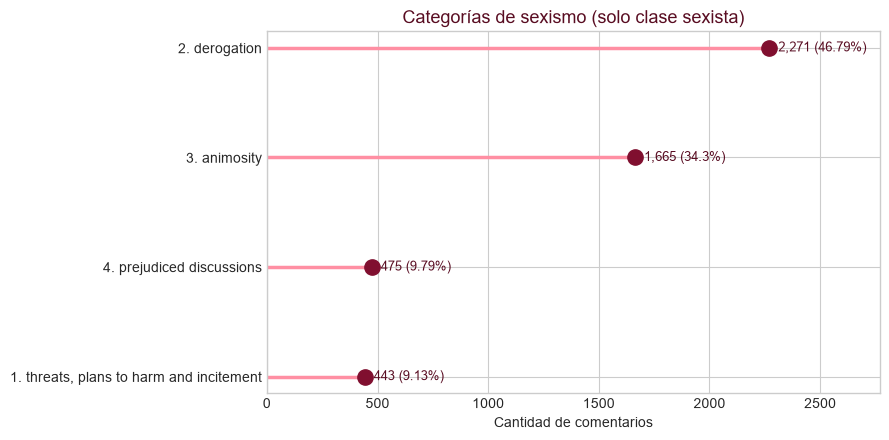

In [15]:
cat_pd = conteo_cat.to_pandas().sort_values("count")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hlines(y=cat_pd["label_category"], xmin=0, xmax=cat_pd["count"],
          color="#FF8FA3", linewidth=2.5)
ax.plot(cat_pd["count"], cat_pd["label_category"], "o",
        markersize=11, color="#800F2F")
for _, row in cat_pd.iterrows():
    ax.text(row["count"] + 40, row["label_category"],
            f'{row["count"]:,} ({row["pct"]}%)', va="center",
            fontsize=9, color="#590D22")
ax.set_xlim(0, cat_pd["count"].max() * 1.22)
ax.set_title("Categorías de sexismo (solo clase sexista)", fontsize=13, color="#590D22")
ax.set_xlabel("Cantidad de comentarios")
plt.tight_layout()
plt.show()

## 7. Análisis univariado — `label_vector`

Tercer nivel de la taxonomía: el vector específico dentro de cada categoría.
Se ordenan de mayor a menor frecuencia (solo clase sexista).

In [16]:
conteo_vec = df_sexist["label_vector"].value_counts(sort=True)
conteo_vec

label_vector,count
str,u32
"""2.1 descriptive attacks""",1024
"""2.2 aggressive and emotive att…",961
"""3.1 casual use of gendered slu…",910
"""3.2 immutable gender differenc…",596
"""4.2 supporting systemic discri…",368
…,…
"""2.3 dehumanising attacks & ove…",286
"""4.1 supporting mistreatment of…",107
"""3.3 backhanded gendered compli…",91


### Visualización — barras horizontales con degradé

Interactivo: tooltip con el conteo exacto de cada vector.

In [17]:
barras_vec = (
    alt.Chart(conteo_vec.to_pandas())
    .mark_bar(cornerRadiusEnd=5)
    .encode(
        x=alt.X("count:Q", title="Cantidad"),
        y=alt.Y("label_vector:N", sort="-x", title=None),
        color=alt.Color("count:Q", scale=alt.Scale(range=["#FFCCD5", "#590D22"]),
                        legend=None),
        tooltip=["label_vector:N", "count:Q"],
    )
    .properties(width=560, height=340, title="Vectores de sexismo (nivel 3 de la taxonomía)")
)
barras_vec

alt.Chart(...)

## 8. Análisis univariado — `split`

Verificación del split original del paper (train / dev / test) y su proporción,
tanto global como dentro de cada clase.

In [18]:
conteo_split = (
    df.group_by("split", "label_sexist")
    .len()
    .sort("split", "label_sexist")
)
conteo_split

split,label_sexist,len
str,str,u32
"""dev""","""not sexist""",1514
"""dev""","""sexist""",486
"""test""","""not sexist""",3030
"""test""","""sexist""",970
"""train""","""not sexist""",10602
"""train""","""sexist""",3398


### Visualización — barras apiladas al 100%

Permite comprobar que el desbalance de clases se mantiene estable en los tres splits
(requisito para que la evaluación sea justa).

In [19]:
split_chart = (
    alt.Chart(conteo_split.to_pandas())
    .mark_bar(cornerRadius=4)
    .encode(
        x=alt.X("split:N", sort=["train", "dev", "test"], title="Split"),
        y=alt.Y("len:Q", stack="normalize", title="Proporción",
                axis=alt.Axis(format="%")),
        color=alt.Color("label_sexist:N",
                        scale=alt.Scale(domain=["not sexist", "sexist"],
                                        range=["#FFB3C1", "#A4133C"]),
                        legend=alt.Legend(title="Clase")),
        tooltip=["split:N", "label_sexist:N", "len:Q"],
    )
    .properties(width=340, height=300, title="Balance de clases por split")
)
split_chart

alt.Chart(...)

## 9. Ingeniería de variables numéricas a partir del texto

El dataset solo tiene columnas de texto y etiquetas, por lo que para poder hacer
análisis de distribuciones y correlaciones se derivan variables numéricas de cada
comentario: longitud, cantidad de palabras, longitud media de palabra, proporción de
mayúsculas, exclamaciones, interrogaciones y menciones anonimizadas ([USER], [URL]).

In [20]:
df_feat = df.with_columns(
    pl.col("text").str.len_chars().alias("n_chars"),
    pl.col("text").str.split(" ").list.len().alias("n_words"),
    pl.col("text").str.count_matches(r"[A-Z]").alias("n_upper"),
    pl.col("text").str.count_matches(r"!").alias("n_exclam"),
    pl.col("text").str.count_matches(r"\?").alias("n_question"),
    pl.col("text").str.count_matches(r"\[USER\]").alias("n_user"),
    pl.col("text").str.count_matches(r"\[URL\]").alias("n_url"),
    (pl.col("label_sexist") == "sexist").cast(pl.Int8).alias("es_sexista"),
).with_columns(
    (pl.col("n_chars") / pl.col("n_words")).round(2).alias("largo_medio_palabra"),
    (pl.col("n_upper") / pl.col("n_chars")).round(4).alias("prop_mayusculas"),
)

df_feat.select(
    "n_chars", "n_words", "largo_medio_palabra", "prop_mayusculas",
    "n_exclam", "n_question", "n_user", "n_url"
).describe()

statistic,n_chars,n_words,largo_medio_palabra,prop_mayusculas,n_exclam,n_question,n_user,n_url
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0,20000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",126.9962,23.3096,5.496942,0.044108,0.18755,0.2154,0.06775,0.1239
"""std""",63.256474,11.709825,1.013494,0.063364,0.730549,0.604831,0.493632,0.358127
"""min""",4.0,1.0,1.8,0.0,0.0,0.0,0.0,0.0
"""25%""",74.0,14.0,5.04,0.0163,0.0,0.0,0.0,0.0
"""50%""",121.0,22.0,5.4,0.0278,0.0,0.0,0.0,0.0
"""75%""",178.0,32.0,5.83,0.05,0.0,0.0,0.0,0.0
"""max""",250.0,58.0,99.0,0.9167,20.0,26.0,21.0,13.0


## 10. Distribución de features — longitud del comentario por clase

Histograma interactivo superpuesto: la distribución de longitud (en caracteres)
de comentarios sexistas frente a no sexistas. Pre-agregado en Polars para que el
gráfico sea liviano.

In [21]:
hist_len = (
    df_feat
    .with_columns((pl.col("n_chars") // 20 * 20).alias("bin_chars"))
    .group_by("bin_chars", "label_sexist")
    .len()
    .sort("bin_chars")
)

hist_chart = (
    alt.Chart(hist_len.to_pandas())
    .mark_area(opacity=0.65, interpolate="monotone", line=True)
    .encode(
        x=alt.X("bin_chars:Q", title="Longitud del comentario (caracteres)"),
        y=alt.Y("len:Q", title="Cantidad de comentarios"),
        color=alt.Color("label_sexist:N",
                        scale=alt.Scale(domain=["not sexist", "sexist"],
                                        range=["#FF8FA3", "#800F2F"]),
                        legend=alt.Legend(title="Clase")),
        tooltip=["bin_chars:Q", "label_sexist:N", "len:Q"],
    )
    .properties(width=640, height=320,
                title="Distribución de longitud del texto por clase")
)
hist_chart

alt.Chart(...)

## 11. Distribución de features — violines por clase

Los violines muestran la forma completa de la distribución (no solo la mediana)
de cantidad de palabras y proporción de mayúsculas, separadas por clase.

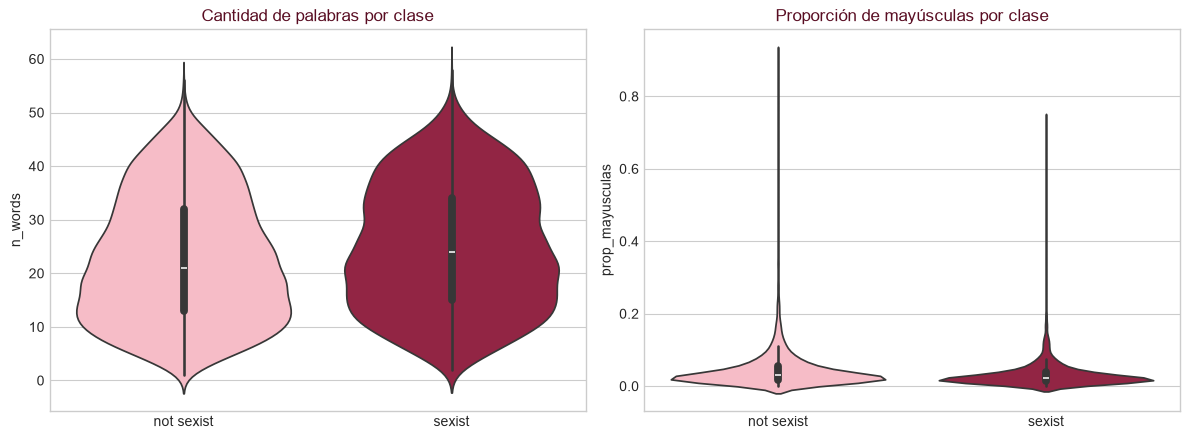

In [22]:
feat_pd = df_feat.select(
    "label_sexist", "n_words", "prop_mayusculas", "n_chars", "n_exclam"
).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.violinplot(data=feat_pd, x="label_sexist", y="n_words", hue="label_sexist",
               palette=["#FFB3C1", "#A4133C"], legend=False, ax=axes[0])
axes[0].set_title("Cantidad de palabras por clase", color="#590D22")
axes[0].set_xlabel("")
sns.violinplot(data=feat_pd, x="label_sexist", y="prop_mayusculas", hue="label_sexist",
               palette=["#FFB3C1", "#A4133C"], legend=False, ax=axes[1])
axes[1].set_title("Proporción de mayúsculas por clase", color="#590D22")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

## 12. Análisis bivariado — longitud del texto según categoría de sexismo

Cruce entre una variable numérica derivada (palabras) y la categoría (nivel 2),
solo dentro de la clase sexista. Permite ver si algún tipo de sexismo tiende a
expresarse en textos más largos o más cortos.

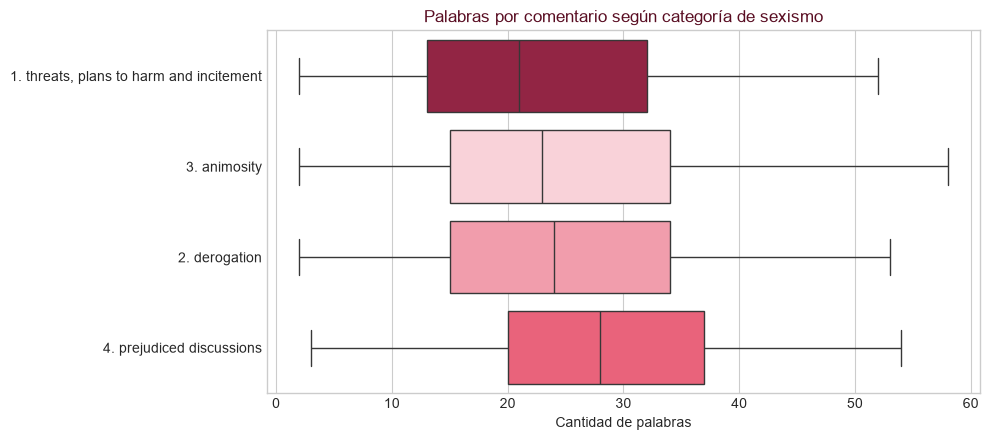

In [23]:
cat_words_pd = (
    df_feat
    .filter(pl.col("label_sexist") == "sexist")
    .select("label_category", "n_words")
    .to_pandas()
)

fig, ax = plt.subplots(figsize=(10, 4.5))
orden = cat_words_pd.groupby("label_category")["n_words"].median().sort_values().index
sns.boxplot(data=cat_words_pd, y="label_category", x="n_words", order=orden,
            hue="label_category", palette=["#FFCCD5", "#FF8FA3", "#FF4D6D", "#A4133C"],
            legend=False, ax=ax)
ax.set_title("Palabras por comentario según categoría de sexismo", color="#590D22")
ax.set_ylabel("")
ax.set_xlabel("Cantidad de palabras")
plt.tight_layout()
plt.show()

## 13. Análisis bivariado — menciones anonimizadas por clase

Proporción de comentarios que contienen al menos un [USER] o [URL], por clase.
Interactivo con tooltips.

In [24]:
menciones = (
    df_feat
    .group_by("label_sexist")
    .agg(
        (pl.col("n_user") > 0).mean().round(4).alias("con [USER]"),
        (pl.col("n_url") > 0).mean().round(4).alias("con [URL]"),
        (pl.col("n_exclam") > 0).mean().round(4).alias("con exclamación"),
        (pl.col("n_question") > 0).mean().round(4).alias("con interrogación"),
    )
    .unpivot(index="label_sexist", variable_name="marcador", value_name="proporcion")
)

menciones_chart = (
    alt.Chart(menciones.to_pandas())
    .mark_bar(cornerRadiusEnd=4)
    .encode(
        x=alt.X("proporcion:Q", axis=alt.Axis(format="%"), title="Proporción de comentarios"),
        y=alt.Y("marcador:N", title=None),
        yOffset="label_sexist:N",
        color=alt.Color("label_sexist:N",
                        scale=alt.Scale(domain=["not sexist", "sexist"],
                                        range=["#FFB3C1", "#A4133C"]),
                        legend=alt.Legend(title="Clase")),
        tooltip=["marcador:N", "label_sexist:N",
                 alt.Tooltip("proporcion:Q", format=".1%")],
    )
    .properties(width=520, height=280,
                title="Marcadores del texto por clase")
)
menciones_chart

alt.Chart(...)

## 14. Análisis multivariado — matriz de correlación

Correlación de Pearson entre todas las variables numéricas derivadas y la variable
objetivo codificada (`es_sexista`: 1 = sexista, 0 = no sexista). La última fila/columna
es la más relevante: qué features se relacionan más con la clase.

In [25]:
cols_num = ["n_chars", "n_words", "largo_medio_palabra", "prop_mayusculas",
            "n_exclam", "n_question", "n_user", "n_url", "es_sexista"]

corr = df_feat.select(cols_num).corr()
corr

n_chars,n_words,largo_medio_palabra,prop_mayusculas,n_exclam,n_question,n_user,n_url,es_sexista
f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.974657,0.046178,-0.099107,0.04763,0.077388,0.046924,0.056274,0.072644
0.974657,1.0,-0.095655,-0.127492,0.036922,0.08271,0.028914,-0.000396,0.07775
0.046178,-0.095655,1.0,0.117038,0.033584,-0.024974,0.039241,0.163133,-0.018787
-0.099107,-0.127492,0.117038,1.0,0.17008,0.007459,0.23762,0.286748,-0.096928
0.04763,0.036922,0.033584,0.17008,1.0,0.035651,0.034369,0.023556,-0.009957
0.077388,0.08271,-0.024974,0.007459,0.035651,1.0,0.004879,-0.030647,-0.042529
0.046924,0.028914,0.039241,0.23762,0.034369,0.004879,1.0,0.08517,-0.030209
0.056274,-0.000396,0.163133,0.286748,0.023556,-0.030647,0.08517,1.0,-0.104022
0.072644,0.07775,-0.018787,-0.096928,-0.009957,-0.042529,-0.030209,-0.104022,1.0


### Visualización — heatmap de correlación

Máscara triangular para no duplicar información; degradé rosa (claro = sin relación,
oscuro = correlación fuerte, en valor absoluto).

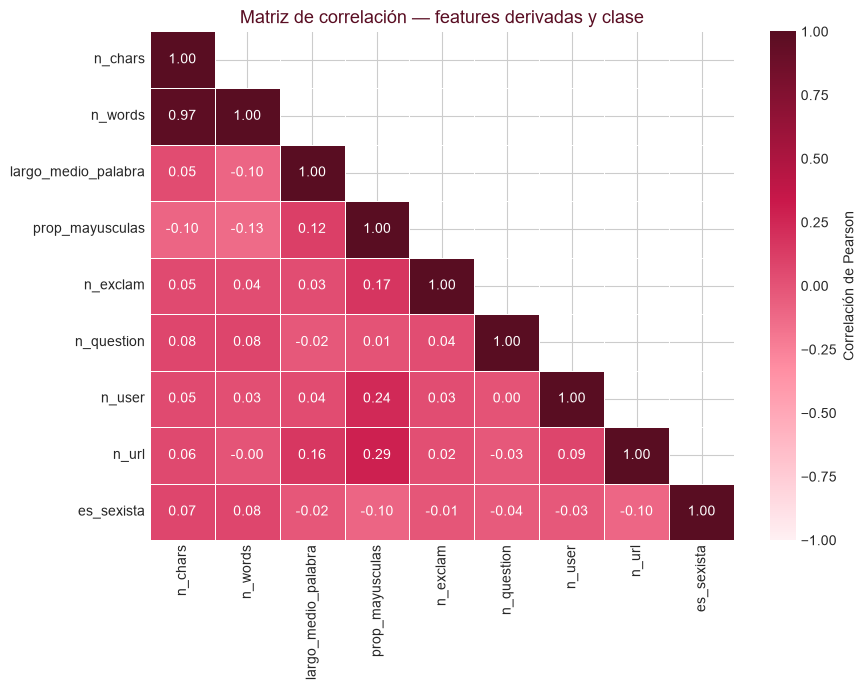

In [26]:
import numpy as np

corr_np = corr.to_numpy()
mask = np.triu(np.ones_like(corr_np, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_np, mask=mask, annot=True, fmt=".2f",
    cmap=CMAP_ROSA, vmin=-1, vmax=1,
    xticklabels=cols_num, yticklabels=cols_num,
    linewidths=0.6, linecolor="white",
    cbar_kws={"label": "Correlación de Pearson"}, ax=ax,
)
ax.set_title("Matriz de correlación — features derivadas y clase", color="#590D22", fontsize=13)
plt.tight_layout()
plt.show()

## 15. Análisis multivariado — features cruzadas por clase y categoría

Dispersión interactiva de longitud frente a proporción de mayúsculas, coloreada por
categoría (muestra aleatoria de la clase sexista para mantener el gráfico legible).
Se puede hacer zoom y ver cada punto con tooltip.

In [27]:
muestra = (
    df_feat
    .filter(pl.col("label_sexist") == "sexist")
    .sample(n=1500, seed=42)
    .select("n_words", "prop_mayusculas", "label_category")
)

scatter = (
    alt.Chart(muestra.to_pandas())
    .mark_circle(size=45, opacity=0.55)
    .encode(
        x=alt.X("n_words:Q", title="Cantidad de palabras"),
        y=alt.Y("prop_mayusculas:Q", title="Proporción de mayúsculas"),
        color=alt.Color("label_category:N",
                        scale=alt.Scale(range=["#590D22", "#C9184A", "#FF4D6D", "#FFB3C1"]),
                        legend=alt.Legend(title="Categoría")),
        tooltip=["n_words:Q", "prop_mayusculas:Q", "label_category:N"],
    )
    .interactive()
    .properties(width=620, height=380,
                title="Longitud vs. mayúsculas por categoría (muestra, clase sexista)")
)
scatter

alt.Chart(...)

## 16. Conclusiones

*(A completar en equipo tras revisar los outputs de cada sección.)*

- Distribución de la variable objetivo:
- Categorías y vectores dominantes:
- Balance por split:
- Features derivadas con más señal:
- Implicaciones para el preprocesamiento y el modelado: